# Post processing

Here we have a few post processing tools to help you understand the output of your simulation.

## Steady state convergence

A steady solution to the Navier-Stokes equations satisfy the steady Navier-Stokes equations

(I'll write the equation properly when I have time)

Or more succinctly, the Navier-Stokes equations in which $\frac{\partial\mathbf{u}}{\partial t} = 0$, and with the addition of a passive scalar, $\frac{\partial\mathbf{\phi}}{\partial t} = 0$.

In `neko-top` we march the Navier-Stokes equations towards a steady solution while using the simulation component with `type: "steady"` to monitoring discrete approximations of the time derivatives, namely

 $r_u = \frac{1}{|\Omega|}\int_\Omega\frac{\partial u}{\partial t} d\Omega \approx  \frac{1}{|\Omega|}\int_\Omega\frac{\Delta u}{\Delta t} d\Omega= \frac{1}{|\Omega|}\int_\Omega\frac{u^{n} - u^{n-1}}{\Delta t}d\Omega$,
  
...

  $r_\phi = \frac{1}{|\Omega|}\int_\Omega\frac{\partial \phi}{\partial t} d\Omega \approx  \frac{1}{|\Omega|}\int_\Omega\frac{\Delta \phi}{\Delta t} d\Omega= \frac{1}{|\Omega|}\int_\Omega\frac{\phi^{n} - \phi^{n-1}}{\Delta t}d\Omega$.

> [!NOTE]
> Currently this is a rather nieve approach to finding steady state solutions, in the future the `neko-top` team intends to implement tools such a `boostconv` (remember to put a link in!) or `SFD` (Selective Frequency Damping)

The output of the steady state residuals $\mathbf{r} = [r_u, r_v, r_w, r_p, r_\phi]$ are saved in `steady_state_data.csv` along with iteration and time.

DESCRIBE THE PARAMETERS LATER.

In [4]:
import pandas as pd

data = pd.read_csv('steady_state_data.csv')
print(data)

          iter    time             u             v             w  \
0         50.0   0.025  7.435849e-01  7.968673e-02  7.968673e-02   
1        100.0   0.050  4.111856e-01  4.303016e-02  4.303016e-02   
2        150.0   0.075  2.791409e-01  2.795370e-02  2.795370e-02   
3        200.0   0.100  2.035758e-01  1.943647e-02  1.943647e-02   
4        250.0   0.125  1.528523e-01  1.395640e-02  1.395640e-02   
...        ...     ...           ...           ...           ...   
30699  29550.0  14.775  2.138358e-13  1.171288e-13  1.160301e-13   
30700  29600.0  14.800  2.137627e-13  1.156415e-13  1.152918e-13   
30701  29650.0  14.825  2.167117e-13  1.171971e-13  1.150801e-13   
30702  29700.0  14.850  2.173019e-13  1.190862e-13  1.199026e-13   
30703  29750.0  14.875  2.191967e-13  1.184019e-13  1.172556e-13   

                  p         t  
0      4.730157e+01  0.004935  
1      1.648913e+01  0.004755  
2      1.213768e+01  0.004611  
3      6.244784e+00  0.004490  
4      1.108104e+00  0.

The data is written continuously, hence, the file is the concatination of all optimization iterations. The following function preprocesses the data to allow for more convenient plotting

> [!NOTE]
> We should really include the optimization iteration in this logfile, but the `simcomp` has no knowledge of the optimization iteration... so it's a bit awkward. We should find a clever way to fix this.

In [29]:
import numpy as np

def split_increasing_segments(matrix):
    # Find indices where the second column (time) resets
    reset_indices = np.where(np.diff(matrix[:, 1]) < 0)[0] + 1
    
    # Split the matrix at these indices
    segments = np.split(matrix, reset_indices)
    
    return segments

data_array = pd.DataFrame(data).to_numpy()
chunks = split_increasing_segments(data_array)


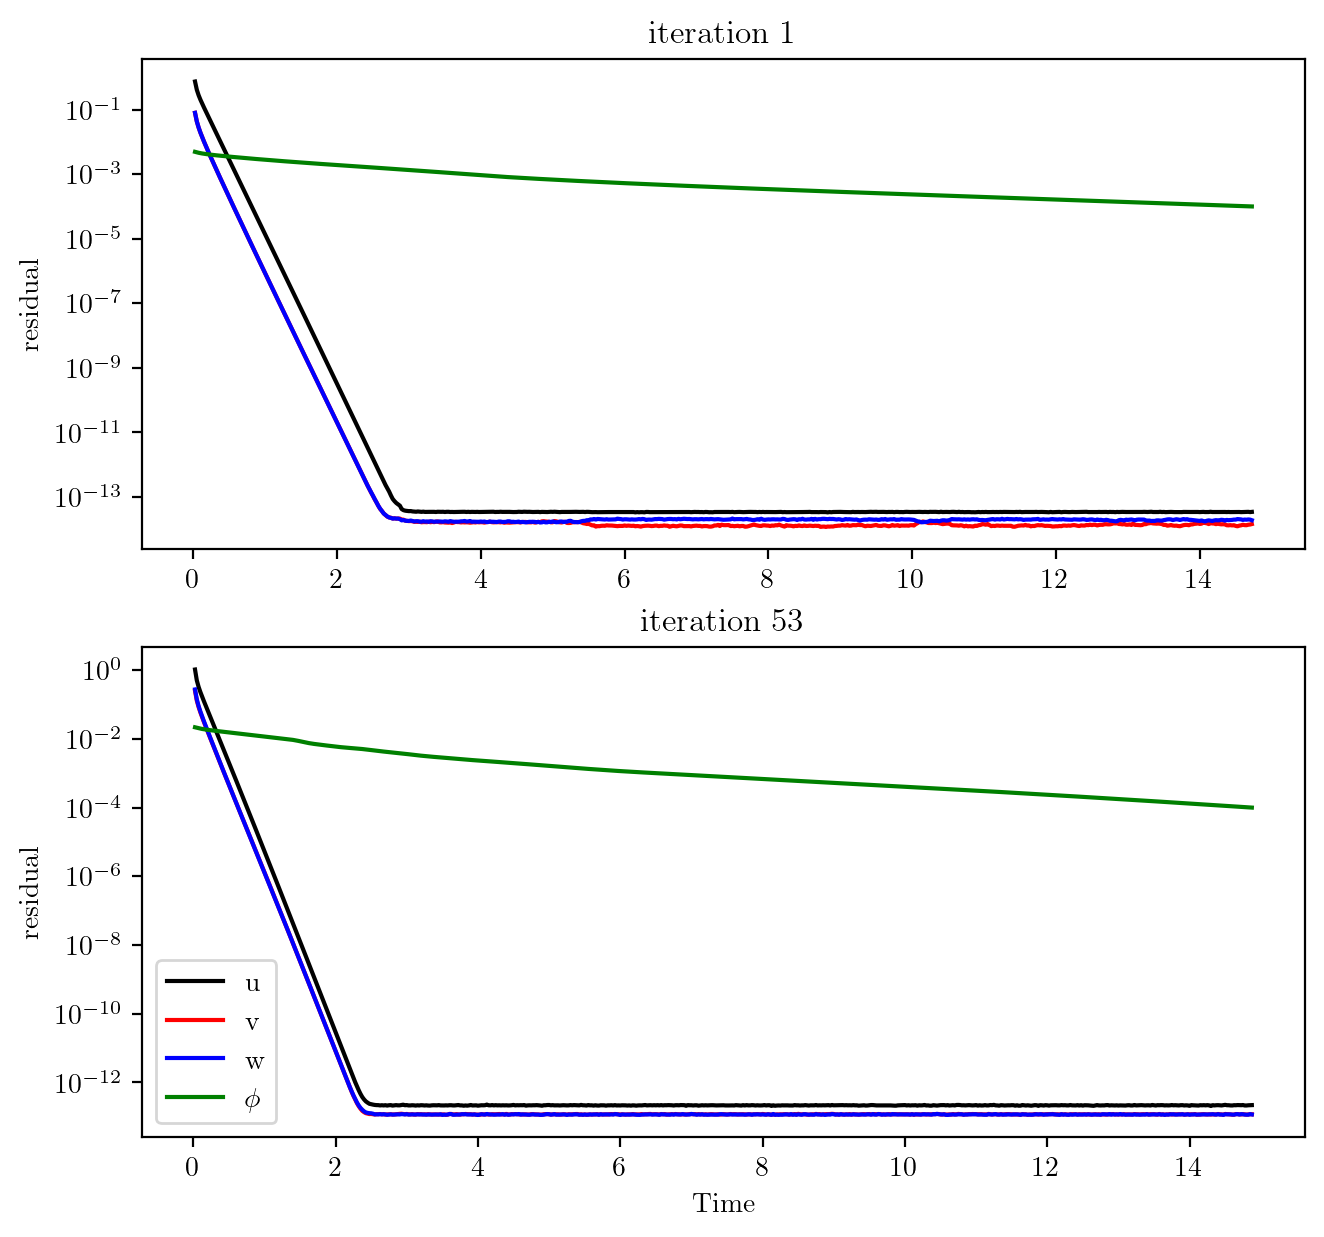

In [46]:
import matplotlib.pyplot as plt
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
import matplotlib as mpl

fig, ax = plt.subplots(2,1, figsize=(7.5, 7), dpi = 200)
ax[0].plot(chunks[0][:, 1], chunks[0][:, 2], '-k', label =  "u")
ax[0].plot(chunks[0][:, 1], chunks[0][:, 3], '-r', label =  "v")
ax[0].plot(chunks[0][:, 1], chunks[0][:, 4], '-b', label =  "w")
ax[0].plot(chunks[0][:, 1], chunks[0][:, 6], '-g', label =  r"$\phi$")
ax[0].set_yscale('log')
ax[0].set_ylabel("residual")                                               
ax[0].set_title('iteration 1')

ax[1].plot(chunks[-1][:, 1], chunks[-1][:, 2], '-k', label =  "u")
ax[1].plot(chunks[-1][:, 1], chunks[-1][:, 3], '-r', label =  "v")
ax[1].plot(chunks[-1][:, 1], chunks[-1][:, 4], '-b', label =  "w")
ax[1].plot(chunks[-1][:, 1], chunks[-1][:, 6], '-g', label =  r"$\phi$")
ax[1].set_yscale('log')
ax[1].set_ylabel("residual")         
ax[1].set_xlabel("Time") 
ax[1].legend()
ax[1].set_title('iteration '+ str(len(chunks)))



plt.show()

## "Convergence"
An important observation here is the rate of convergence between the velocity and the passive scalar. The Peclet number is defined by

$Pe = \frac{\text{advective transport rate}}{\text{diffusive transport rate}}$.

Particularly with configurations at low Reynolds number and high Peclet number, the transport rate due to molecular diffusion will be significantly longer than advection, making this quantity excruiatingly difficult to converge.

Of course, a wonderful mechanism by which advection can be utilized to transport a passive scalar throughout a fluid is by harnessing turbulence, a mechanism inteded to be explored in the larger CEEC project on turbulent mixing.

## TODO
I'm pretty confident for these test problems we should ignore the passive scalar in the metrics for convergence. But I haven't done enough testing to say for sure, and I'm too scared to hard code something like that.